## Loading the Dataset

In [ ]:
!pip install tensorflow

import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist, fashion_mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = fashion_mnist.load_data()

## Data Exploration

### Visualizing the Digits

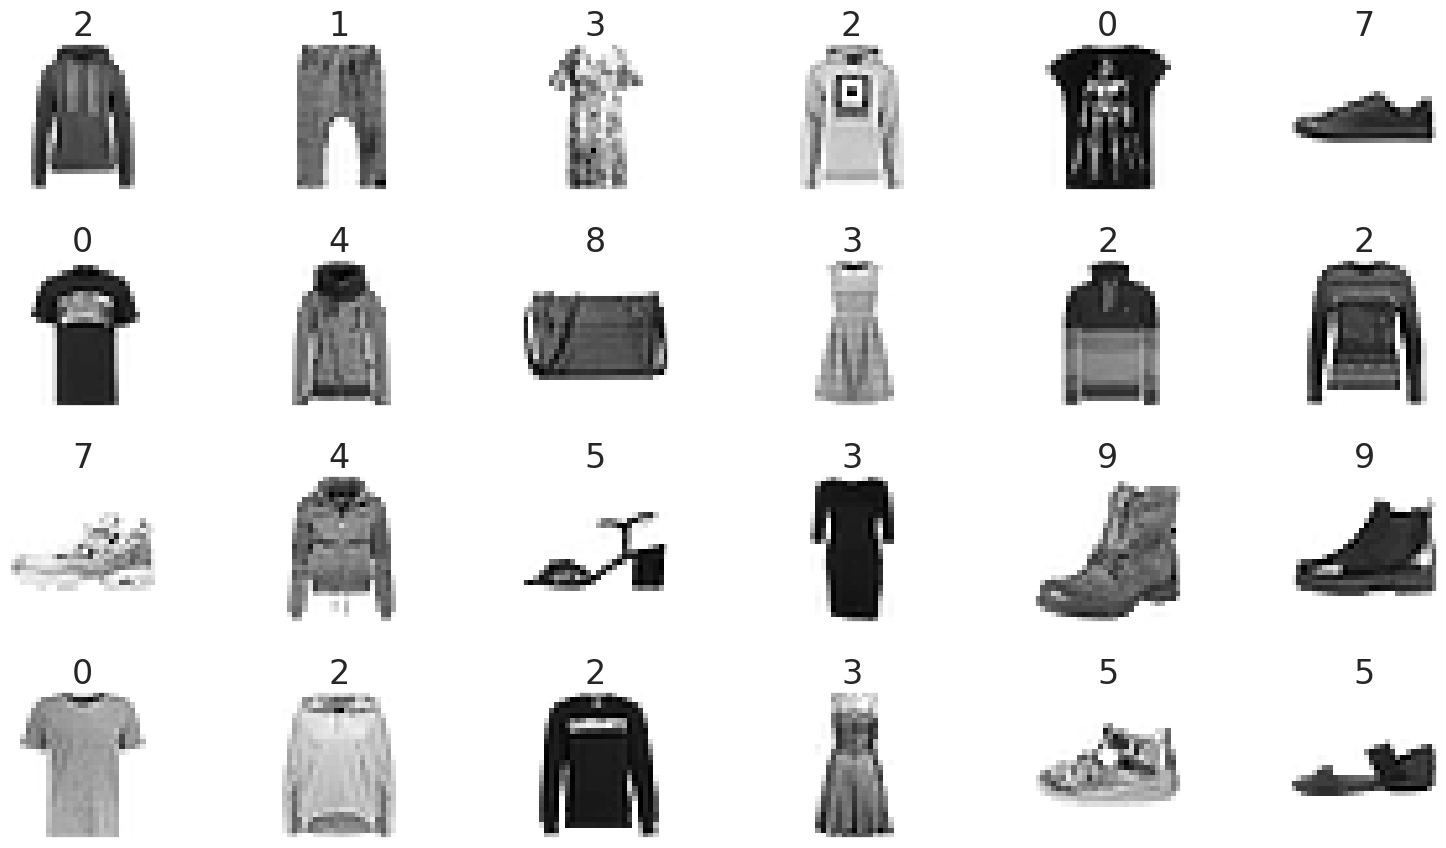

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(font_scale=2)

index = np.random.choice(np.arange(len(X_train_fashion)), 24, replace=False)
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 9))

for item in zip(axes.ravel(), X_train_fashion[index], y_train_fashion[index]):
    axes, image, target = item
    axes.imshow(image, cmap=plt.cm.gray_r)
    axes.set_xticks([])  # remove x-axis tick marks
    axes.set_yticks([])  # remove y-axis tick marks
    axes.set_title(target)
plt.tight_layout()

## Data Preparation

### Reshape the Image Data
- Reshape the image data for use in our covnet

In [ ]:
print("MNIST: ")
X_train = X_train.reshape((60000, 28, 28, 1))
print(X_train.shape)

X_test = X_test.reshape((10000, 28, 28, 1))
print(X_test.shape, end="\n\n")

print("Fashion MNIST: ")
X_train_fashion = X_train_fashion.reshape((60000, 28, 28, 1))
print(X_train_fashion.shape)

X_test_fashion = X_test_fashion.reshape((10000, 28, 28, 1))
print(X_test_fashion.shape)

MNIST: 
(60000, 28, 28, 1)
(10000, 28, 28, 1)

Fashion MNIST: 
(60000, 28, 28, 1)
(10000, 28, 28, 1)


### Normalizing the Image Data

In [ ]:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

X_train_fashion = X_train_fashion.astype('float32') / 255
X_test_fashion = X_test_fashion.astype('float32') / 255

### One-Hot Encoding: Converting Labels from Integers to Categorical Data

In [ ]:
from keras.utils import to_categorical

if y_train.shape == (60000,):
  y_train = to_categorical(y_train)

if y_test.shape == (10000,):
  y_test = to_categorical(y_test)

print("MNIST: ")
print(y_train.shape)
print(y_train[0])
print(y_test.shape, end="\n\n")

if y_train_fashion.shape == (60000,):
  y_train_fashion = to_categorical(y_train_fashion)

if y_test_fashion.shape == (10000,):
  y_test_fashion = to_categorical(y_test_fashion)

print("Fashion MNIST: ")
print(y_train_fashion.shape)
print(y_train_fashion[0])
print(y_test_fashion.shape)

MNIST: 
(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
(10000, 10)

Fashion MNIST: 
(60000, 10)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
(10000, 10)


## Creating the Neural Network

In [ ]:
from keras.models import Sequential

cnn = Sequential()
cnn2 = Sequential()

### Adding a Convolution Layer

In [ ]:
from keras.layers import Conv2D, Dense, Flatten, MaxPooling2D

cnn.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Adding a Pooling Layer

In [ ]:
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn2.add(MaxPooling2D(pool_size=(2, 2)))

### Adding Another Convolutional and Pooling Layer

In [ ]:
cnn.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))

cnn2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
cnn2.add(MaxPooling2D(pool_size=(2, 2)))

### Flattening the Results


In [ ]:
cnn.add(Flatten())
cnn2.add(Flatten())

### Adding a Dense Layer to Reduce the Number of Features

In [ ]:
cnn.add(Dense(units=128, activation='relu'))
cnn2.add(Dense(units=128, activation='relu'))

### Adding Another Dense Layer to Produce the Final Output

In [ ]:
cnn.add(Dense(units=10, activation='softmax'))
cnn2.add(Dense(units=10, activation='softmax'))

### Printing the Model's Summary

In [ ]:
cnn2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Model

In [ ]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Training and Evaluating the Model
* Accuracy seems to be less for Fashion MNIST model, maybe because it's easier to evaluate numbers than clothes?

In [ ]:
cnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

cnn2.fit(X_train_fashion, y_train_fashion, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9553 - loss: 0.1435 - val_accuracy: 0.9908 - val_loss: 0.0410
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9868 - loss: 0.0434 - val_accuracy: 0.9893 - val_loss: 0.0364
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.9904 - loss: 0.0306 - val_accuracy: 0.9870 - val_loss: 0.0442
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9936 - loss: 0.0203 - val_accuracy: 0.9898 - val_loss: 0.0369
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9944 - loss: 0.0168 - val_accuracy: 0.9908 - val_loss: 0.0318
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 45ms/step - accuracy: 0.8245 - loss: 0.4799 - val_accuracy: 0.8777 - val_loss: 0.3389
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.8873 - loss: 0.3099 - val_accuracy: 0.8685 - val_loss: 0.3555
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9031 - loss: 0.2628 - val_accu

In [ ]:
loss, accuracy = cnn.evaluate(X_test, y_test)

print(f'Loss for MNIST: {loss:.4f}')
print(f'Accuracy for MNIST: {accuracy:.4f}', end="\n\n")

loss2, accuracy2 = cnn2.evaluate(X_test_fashion, y_test_fashion)

print(f'Loss for Fashion MNIST: {loss2:.4f}')
print(f'Accuracy for Fashion MNIST: {accuracy2:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9898 - loss: 0.0316
Loss for MNIST: 0.0316
Accuracy for MNIST: 0.9898

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9053 - loss: 0.2508
Loss for Fashion MNIST: 0.2508
Accuracy for Fashion MNIST: 0.9053


## Testing with 4096 neurons

In [ ]:
cnn3 = Sequential()
cnn3.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn3.add(MaxPooling2D(pool_size=(2, 2)))

cnn3.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
cnn3.add(MaxPooling2D(pool_size=(2, 2)))

cnn3.add(Flatten())

cnn3.add(Dense(units=4096, activation='relu'))
cnn3.add(Dense(units=128, activation='relu'))
cnn3.add(Dense(units=10, activation='softmax'))

cnn3.summary()

cnn3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cnn3.fit(X_train_fashion, y_train_fashion, epochs=5, batch_size=64, validation_split=0.1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    13,111,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,711,498 (52.31 MB)

 Trainable params: 13,711,498 (52.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 174s 205ms/step - accuracy: 0.8471 - loss: 0.4175 - val_accuracy: 0.8913 - val_loss: 0.2895
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 173s 205ms/step - accuracy: 0.8999 - loss: 0.2695 - val_accuracy: 0.8948 - val_loss: 0.2771
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 176s 208ms/step - accuracy: 0.9161 - loss: 0.2221 - val_accuracy: 0.9152 - val_loss: 0.2423
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 176s 208ms/step - accuracy: 0.9302 - loss: 0.1864 - val_accuracy: 0.9177 - val_loss: 0.2340
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 176s 208ms/step - accuracy: 0.9419 - loss: 0.1544 - val_accuracy: 0.9122 - val_loss: 0.2520
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9069 - loss: 0.2677
Loss for Fashion MNIST with 4096 neurons Dense layer: 0.2508
Accuracy for Fashion MNIST with 4096 neurons Dense layer: 0.9053


In [132]:
loss3, accuracy3 = cnn3.evaluate(X_test_fashion, y_test_fashion)

print(f'Loss for Fashion MNIST with 4096 neurons Dense layer: {loss3:.4f}')
print(f'Accuracy for Fashion MNIST with 4096 neurons Dense layer: {accuracy3:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9069 - loss: 0.2677
Loss for Fashion MNIST with 4096 neurons Dense layer: 0.2677
Accuracy for Fashion MNIST with 4096 neurons Dense layer: 0.9069
